In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn torch


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


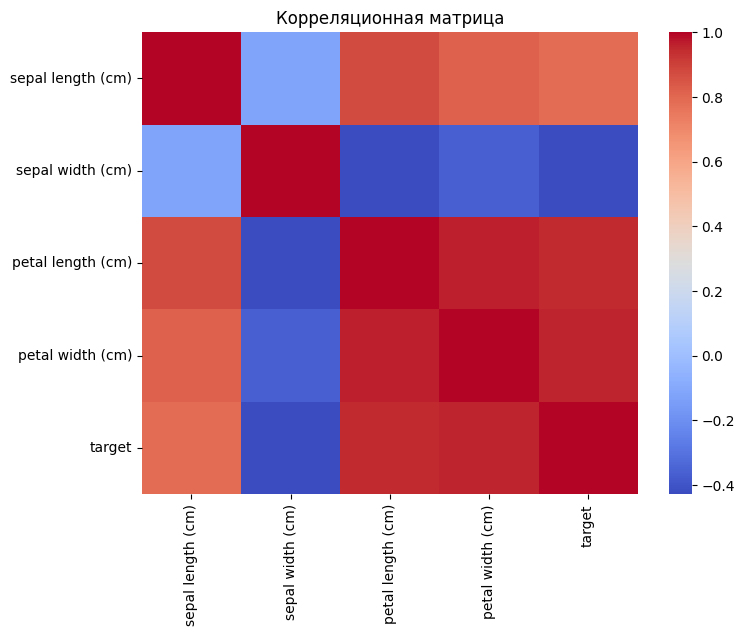

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Корреляционная матрица")
plt.show()

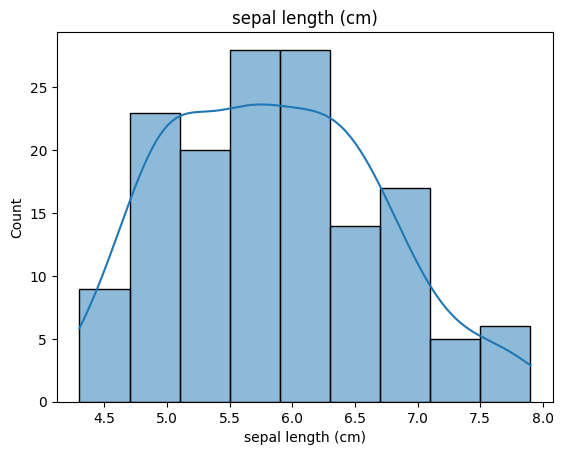

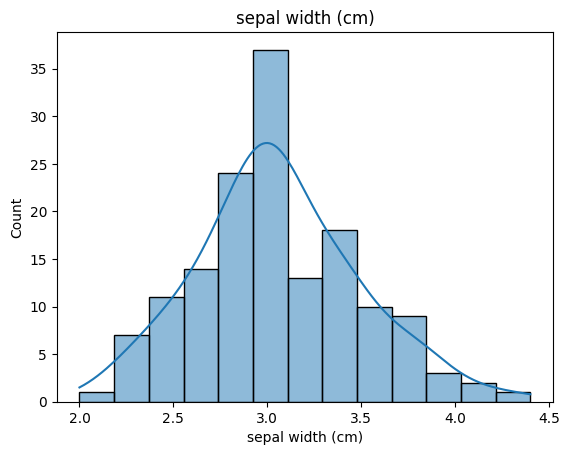

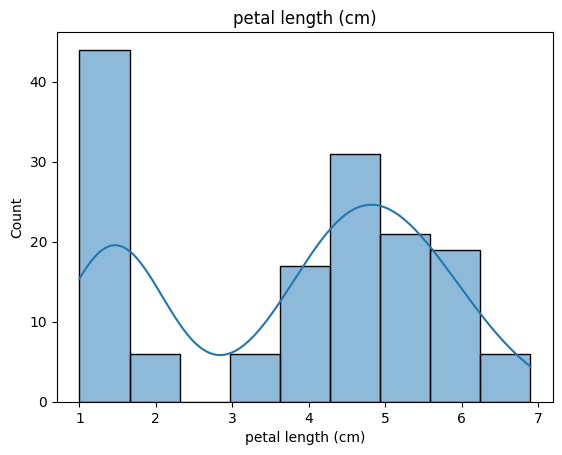

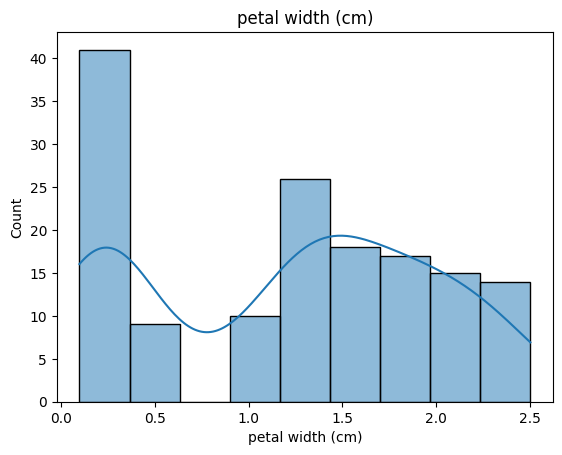

In [13]:
for col in feature_names:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

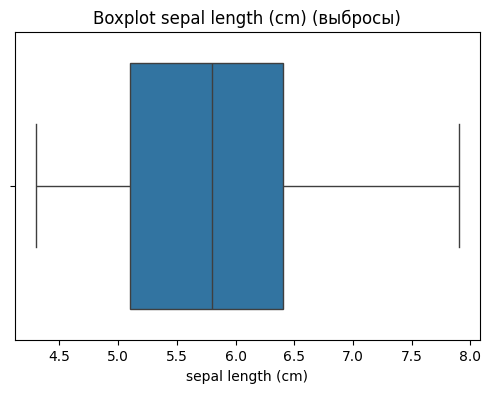

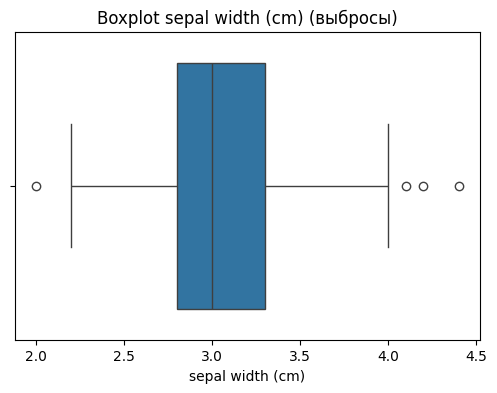

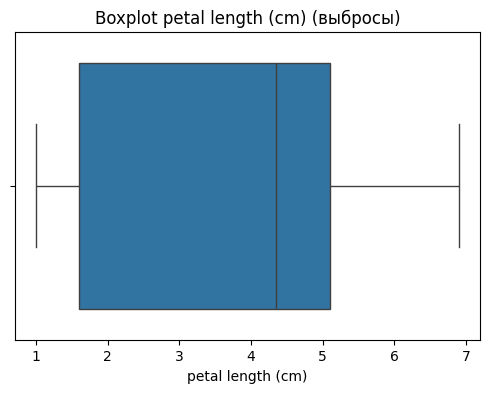

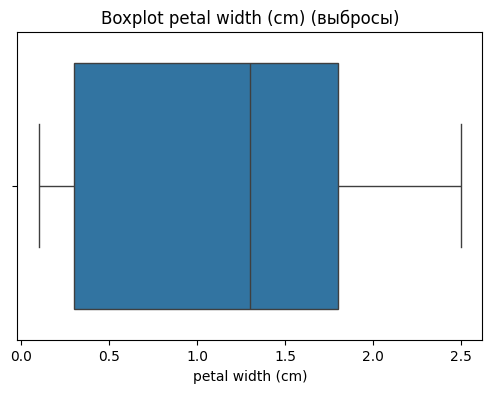

In [ ]:
for col in feature_names:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col} (выбросы)")
    plt.show()

In [ ]:

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

model = LogisticRegressionModel(4, 3)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train={train_loss:.4f}, Test={test_loss:.4f}")

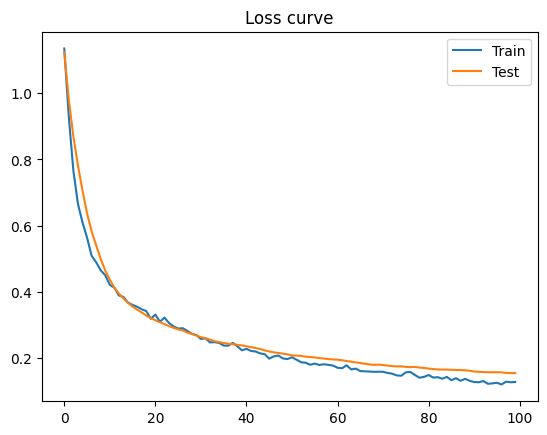

In [ ]:
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.legend()
plt.title("Loss curve")
plt.show()

In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(yb.numpy())
        y_pred.extend(preds.numpy())

print("\nAccuracy:", accuracy_score(y_true, y_pred))

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.9666666666666667

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.89      0.94         9
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



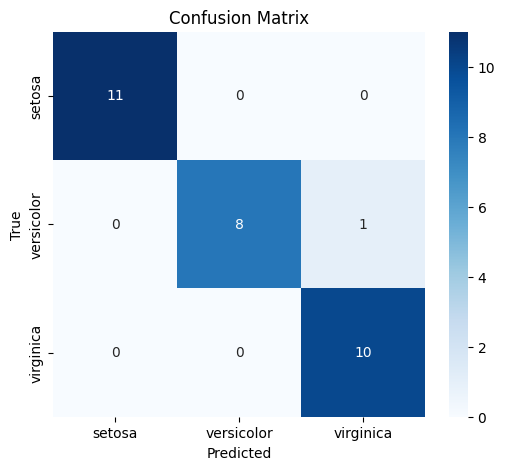

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("\nКоэффициенты PyTorch:")
for i, class_name in enumerate(class_names):
    print(f"\nКласс {class_name}:")
    for fname, coef in zip(feature_names, model.linear.weight[i].detach().numpy()):
        print(f"{fname}: {coef:.4f}")


Коэффициенты PyTorch:

Класс setosa:
sepal length (cm): -1.5632
sepal width (cm): 1.6457
petal length (cm): -1.6572
petal width (cm): -2.2640

Класс versicolor:
sepal length (cm): 0.8619
sepal width (cm): -0.3165
petal length (cm): 0.0141
petal width (cm): -1.3269

Класс virginica:
sepal length (cm): 0.4400
sepal width (cm): -0.7054
petal length (cm): 2.0656
petal width (cm): 2.6912
